# MinHash/LSH Demo


In [1]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

pd.set_option("display.max_colwidth", 160)
plt.style.use("seaborn-v0_8-whitegrid")


def resolve_artifact_dir() -> Path:
    cwd = Path.cwd().resolve()
    candidates = [cwd, cwd.parent]
    for candidate in candidates:
        artifact_dir = candidate / "jupyter" / "output" / "lsh"
        if artifact_dir.exists():
            return artifact_dir
    raise FileNotFoundError("Could not find jupyter/output/lsh. Run the pipeline scripts first.")


def preview_text(text: object, width: int = 120) -> str:
    compact = " ".join(str(text).split())
    return compact if len(compact) <= width else compact[: width - 1] + "…"


def top_cluster_table(clusters: pd.DataFrame, scale: pd.DataFrame, top_n: int = 10) -> pd.DataFrame:
    summary = (
        clusters.groupby("cluster_id", as_index=False)["cluster_size"]
        .max()
        .sort_values(["cluster_size", "cluster_id"], ascending=[False, True])
        .head(top_n)
    )
    sample = (
        clusters[["cluster_id", "tweet_id"]]
        .merge(scale[["tweet_id", "norm_text"]], on="tweet_id", how="left")
        .sort_values(["cluster_id", "tweet_id"])
        .groupby("cluster_id", as_index=False)
        .first()
    )
    table = summary.merge(sample, on="cluster_id", how="left")
    table["example_tweet"] = table["norm_text"].map(preview_text)
    return table[["cluster_id", "cluster_size", "tweet_id", "example_tweet"]]


def pair_examples(verified: pd.DataFrame, lookup: pd.DataFrame, mode: str, top_n: int = 5) -> pd.DataFrame:
    merged = verified.merge(
        lookup.add_suffix("_left"),
        left_on="tweet_id_left",
        right_on="tweet_id_left",
        how="left",
    ).merge(
        lookup.add_suffix("_right"),
        left_on="tweet_id_right",
        right_on="tweet_id_right",
        how="left",
    )

    if mode == "exact":
        table = merged[merged["jaccard"] == 1.0].copy()
        table = table.drop_duplicates(subset=["norm_text_left"])
        table = table.sort_values(["tweet_id_left", "tweet_id_right"])
    elif mode == "near":
        table = merged[(merged["jaccard"] < 1.0) & (merged["jaccard"] >= 0.8)].copy()
        table = table.drop_duplicates(subset=["norm_text_left", "norm_text_right"])
        table = table.sort_values(["jaccard", "tweet_id_left"], ascending=[False, True])
    else:
        raise ValueError("mode must be 'exact' or 'near'")

    table["left_text"] = table["text_left"].map(preview_text)
    table["right_text"] = table["text_right"].map(preview_text)
    return table[["tweet_id_left", "tweet_id_right", "jaccard", "left_text", "right_text"]].head(top_n)


def cluster_samples(cluster_id: int, clusters: pd.DataFrame, scale: pd.DataFrame, top_n: int = 8) -> pd.DataFrame:
    table = (
        clusters[clusters["cluster_id"] == cluster_id]
        .merge(scale[["tweet_id", "text"]], on="tweet_id", how="left")
        .sort_values("tweet_id")
        .head(top_n)
        .copy()
    )
    table["text_preview"] = table["text"].map(lambda value: preview_text(value, width=140))
    return table[["cluster_id", "cluster_size", "tweet_id", "text_preview"]]


ARTIFACT_DIR = resolve_artifact_dir()
FIGURE_DIR = ARTIFACT_DIR / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

METRICS = json.loads((ARTIFACT_DIR / "metrics.json").read_text(encoding="utf-8"))
SCALE = pd.read_parquet(ARTIFACT_DIR / "scale_shingles.parquet")
VERIFIED = pd.read_parquet(ARTIFACT_DIR / "verified_pairs.parquet")
CLUSTERS = pd.read_parquet(ARTIFACT_DIR / "clusters.parquet")
LOOKUP = SCALE[["tweet_id", "text", "norm_text"]].copy()

CONFIG_RANKING = pd.DataFrame(METRICS["run_lsh"]["config_results"])
CLUSTER_SIZE_DF = (
    CLUSTERS.groupby("cluster_id", as_index=False)["cluster_size"]
    .max()
    .sort_values(["cluster_size", "cluster_id"], ascending=[False, True])
)
TOP_CLUSTERS = top_cluster_table(CLUSTERS, SCALE, top_n=10)
EXACT_EXAMPLES = pair_examples(VERIFIED, LOOKUP, mode="exact", top_n=5)
NEAR_EXAMPLES = pair_examples(VERIFIED, LOOKUP, mode="near", top_n=5)
SELECTED = METRICS["run_lsh"]["selected_config"]
LARGEST_CLUSTER_ID = int(TOP_CLUSTERS.iloc[0]["cluster_id"])

ARTIFACT_DIR

WindowsPath('F:/UK-Russia/jupyter/output/lsh')

## 1. Executive Summary

In [2]:
singleton_clusters = int((CLUSTER_SIZE_DF["cluster_size"] == 1).sum())
repeat_clusters = int(len(CLUSTER_SIZE_DF) - singleton_clusters)

overview_df = pd.DataFrame(
    [
        {"metric": "Baseline subset", "value": f"{METRICS['extract_subsets']['baseline_rows']:,} tweets"},
        {"metric": "Scale subset", "value": f"{METRICS['extract_subsets']['scale_rows']:,} tweets"},
        {"metric": "Rows kept after shingles", "value": f"{METRICS['build_shingles']['scale_shingles']['kept_rows']:,} tweets"},
        {"metric": "Baseline exact positives", "value": f"{METRICS['baseline']['positive_pairs']:,} pairs"},
        {"metric": "LSH candidates", "value": f"{METRICS['run_lsh']['scale_run']['candidate_pairs']:,} pairs"},
        {"metric": "Verified near-duplicates", "value": f"{METRICS['verify_and_cluster']['verified_pairs']:,} pairs"},
        {"metric": "Total clusters", "value": f"{METRICS['verify_and_cluster']['clusters']:,}"},
        {"metric": "Repeated-content clusters", "value": f"{repeat_clusters:,}"},
        {"metric": "Largest cluster", "value": f"{METRICS['verify_and_cluster']['largest_cluster_size']:,} tweets"},
        {"metric": "Winning config", "value": SELECTED['config_name']},
    ]
)

display(overview_df)

,metric,value
0,Baseline subset,"3,000 tweets"
1,Scale subset,"50,000 tweets"
2,Rows kept after shingles,"49,852 tweets"
3,Baseline exact positives,111 pairs
4,LSH candidates,"36,487 pairs"
5,Verified near-duplicates,"31,875 pairs"
6,Total clusters,"42,519"
7,Repeated-content clusters,"3,150"
8,Largest cluster,60 tweets
9,Winning config,k3_perm128_bands16_rows8


## 2. Dashboard

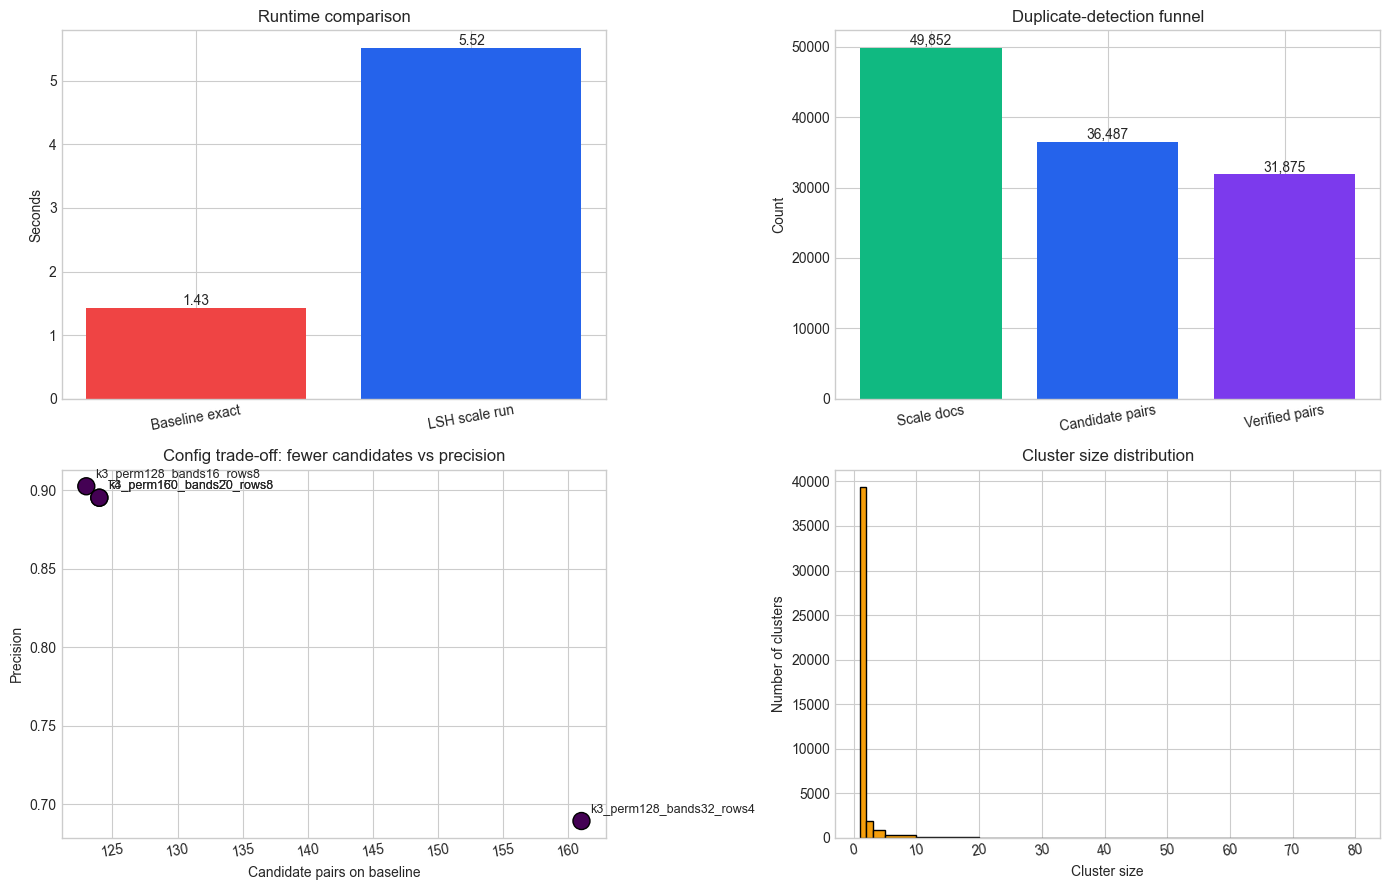

In [3]:
runtime_df = pd.DataFrame(
    [
        {"stage": "Baseline exact", "runtime_seconds": METRICS['baseline']['runtime_seconds']},
        {"stage": "LSH scale run", "runtime_seconds": METRICS['run_lsh']['scale_run']['runtime_seconds']},
    ]
)
funnel_df = pd.DataFrame(
    [
        {"stage": "Scale docs", "count": METRICS['build_shingles']['scale_shingles']['kept_rows']},
        {"stage": "Candidate pairs", "count": METRICS['run_lsh']['scale_run']['candidate_pairs']},
        {"stage": "Verified pairs", "count": METRICS['verify_and_cluster']['verified_pairs']},
    ]
)

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

axes[0, 0].bar(runtime_df['stage'], runtime_df['runtime_seconds'], color=['#ef4444', '#2563eb'])
axes[0, 0].set_title('Runtime comparison')
axes[0, 0].set_ylabel('Seconds')
for idx, value in enumerate(runtime_df['runtime_seconds']):
    axes[0, 0].text(idx, value, f'{value:.2f}', ha='center', va='bottom')

axes[0, 1].bar(funnel_df['stage'], funnel_df['count'], color=['#10b981', '#2563eb', '#7c3aed'])
axes[0, 1].set_title('Duplicate-detection funnel')
axes[0, 1].set_ylabel('Count')
for idx, value in enumerate(funnel_df['count']):
    axes[0, 1].text(idx, value, f'{int(value):,}', ha='center', va='bottom')

config_plot = CONFIG_RANKING.copy()
axes[1, 0].scatter(
    config_plot['candidate_pairs'],
    config_plot['precision'],
    s=150,
    c=config_plot['recall'],
    cmap='viridis',
    edgecolors='black',
)
for row in config_plot.itertuples(index=False):
    axes[1, 0].annotate(row.config_name, (row.candidate_pairs, row.precision), xytext=(6, 6), textcoords='offset points', fontsize=9)
axes[1, 0].set_title('Config trade-off: fewer candidates vs precision')
axes[1, 0].set_xlabel('Candidate pairs on baseline')
axes[1, 0].set_ylabel('Precision')

cluster_hist = CLUSTER_SIZE_DF['cluster_size']
bins = [1, 2, 3, 5, 10, 20, 40, 60, 80]
axes[1, 1].hist(cluster_hist, bins=bins, color='#f59e0b', edgecolor='black')
axes[1, 1].set_title('Cluster size distribution')
axes[1, 1].set_xlabel('Cluster size')
axes[1, 1].set_ylabel('Number of clusters')

for ax in axes.flat:
    ax.tick_params(axis='x', rotation=10)

plt.tight_layout()
fig.savefig(FIGURE_DIR / 'dashboard.png', dpi=160, bbox_inches='tight')
plt.show()

## 3. Vì sao chọn config này

In [4]:
selection_view = CONFIG_RANKING[
    ['config_name', 'shingle_size', 'num_perm', 'bands', 'rows', 'candidate_pairs', 'precision', 'recall']
].copy()
selection_view['selected'] = selection_view['config_name'].eq(SELECTED['config_name'])

display(selection_view)

display(Markdown(
    f"**Config thắng:** `{SELECTED['config_name']}`  \n"
    f"- Recall trên baseline = **{CONFIG_RANKING.iloc[0]['recall']:.3f}**  \n"
    f"- Candidate pairs trên baseline = **{int(CONFIG_RANKING.iloc[0]['candidate_pairs']):,}**  \n"
    f"- Precision trên baseline = **{CONFIG_RANKING.iloc[0]['precision']:.3f}**  \n"
    "- Đây là config ít candidate nhất trong nhóm đạt recall 1.0 nên phù hợp làm cấu hình demo/final."
))

,config_name,shingle_size,num_perm,bands,rows,candidate_pairs,precision,recall,selected
0,k3_perm128_bands16_rows8,3,128,16,8,123,0.902439,1.0,True
1,k3_perm160_bands20_rows8,3,160,20,8,124,0.895161,1.0,False
2,k4_perm160_bands20_rows8,4,160,20,8,124,0.895161,1.0,False
3,k3_perm128_bands32_rows4,3,128,32,4,161,0.689441,1.0,False


**Config thắng:** `k3_perm128_bands16_rows8`  
- Recall trên baseline = **1.000**  
- Candidate pairs trên baseline = **123**  
- Precision trên baseline = **0.902**  
- Đây là config ít candidate nhất trong nhóm đạt recall 1.0 nên phù hợp làm cấu hình demo/final.

## 4. Top cluster lớn nhất

,cluster_id,cluster_size,tweet_id,example_tweet
0,1744,60,1566105622046982149,"#russia soldiers, cowards #putin don't obey! throw away your weapons and go home! and eat a hot dinner with the whole f…"
1,26630,57,1633251318562189313,this is going to be iconic. #tbilisi #georgia
2,35358,52,1643480275525967874,relax. it is not #ukraine just a holy place of worship in occupied jerusalem.
3,36360,50,1644863675591716864,to @elonmusk 1. is this a violation of tos calling for genocide of #ukraine 2. how is a terrorist state verified 3. why…
4,31288,47,1638499744581296129,"a peaceful day in the world, another horrible day in ukraine. russian rocket just hit a section of residential building…"
5,23119,43,1629515116042649606,polish media accidently recorded #zelensky's double when they covered #biden's visit to #kyiv #awkward
6,32740,40,1640168366399959041,"here's why i believe ukraine was, and remains, such a threat to vladimir #putin: in 1989, putin was a kgb officer in dr…"
7,30268,35,1637487690735140865,equal justice matter !! the icc alleges #putin is responsible for war crimes committed in #ukraine️ . @abiyahmedali &am…
8,34380,32,1642198080228593665,#anonymous has been saying this since #elon bought #twitter twitter's open-sourced algorithm reveals that topics about …
9,376,30,1561779495509565441,"fick dich, putin! (german)"


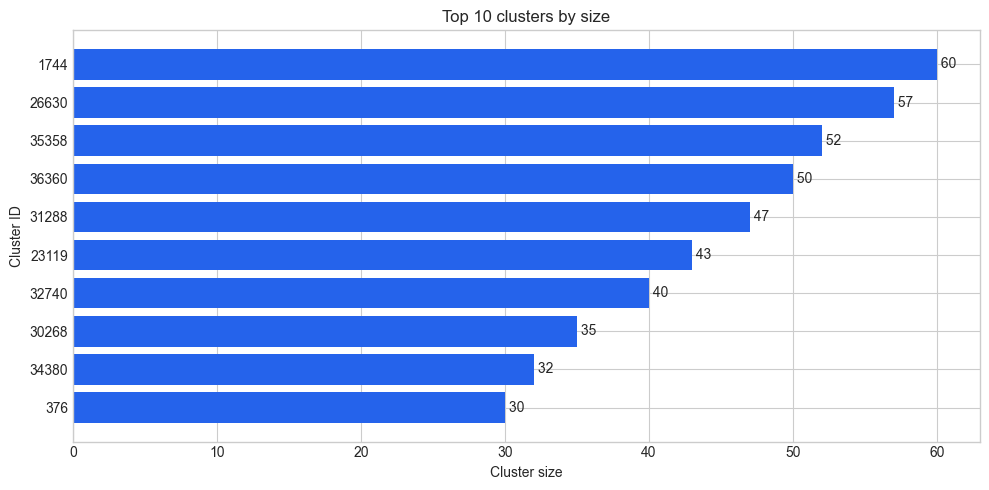

In [5]:
display(TOP_CLUSTERS)

fig, ax = plt.subplots(figsize=(10, 5))
plot_df = TOP_CLUSTERS.iloc[::-1]
ax.barh(plot_df['cluster_id'].astype(str), plot_df['cluster_size'], color='#2563eb')
ax.set_title('Top 10 clusters by size')
ax.set_xlabel('Cluster size')
ax.set_ylabel('Cluster ID')
for idx, value in enumerate(plot_df['cluster_size']):
    ax.text(value, idx, f' {int(value)}', va='center')
plt.tight_layout()
fig.savefig(FIGURE_DIR / 'top_clusters.png', dpi=160, bbox_inches='tight')
plt.show()

In [6]:
largest_cluster_preview = cluster_samples(LARGEST_CLUSTER_ID, CLUSTERS, SCALE, top_n=8)
display(Markdown(f"**Largest cluster:** `{LARGEST_CLUSTER_ID}` with **{int(TOP_CLUSTERS.iloc[0]['cluster_size'])}** tweets"))
display(largest_cluster_preview)

**Largest cluster:** `1744` with **60** tweets

,cluster_id,cluster_size,tweet_id,text_preview
0,1744,60,1566105622046982149,"#Russia Soldiers, cowards #Putin Don't obey! Throw away your weapons and go home! And eat a hot dinner with the whole family. Stay close to…"
1,1744,60,1569845632227233793,"#Russia Soldiers, cowards #Putin Don't obey! Throw away your weapons and go home! And eat a hot dinner with the whole family. Stay close to…"
2,1744,60,1571045843826003973,"#Russia Soldiers, cowards #Putin Don't obey! Throw away your weapons and go home! And eat a hot dinner with the whole family. Stay close to…"
3,1744,60,1573177229076463616,"#Russia Soldiers, cowards #Putin Don't obey! Throw away your weapons and go home! And eat a hot dinner with the whole family. Stay close to…"
4,1744,60,1574024846530711552,"#Russia Soldiers, cowards #Putin Don't obey! Throw away your weapons and go home! And eat a hot dinner with the whole family. Stay close to…"
5,1744,60,1574028081442226177,"#Russia Soldiers, cowards #Putin Don't obey! Throw away your weapons and go home! And eat a hot dinner with the whole family. Stay close to…"
6,1744,60,1574797082040627200,"#Russia Soldiers, cowards #Putin Don't obey! Throw away your weapons and go home! And eat a hot dinner with the whole family. Stay close to…"
7,1744,60,1574908247685107713,"#Russia Soldiers, cowards #Putin Don't obey! Throw away your weapons and go home! And eat a hot dinner with the whole family. Stay close to…"


## 5. Exact duplicate tiêu biểu

In [7]:
display(EXACT_EXAMPLES)

,tweet_id_left,tweet_id_right,jaccard,left_text,right_text
0,1560520700485582848,1564805183632195585,1.0,"Ewch i fuck eich hun, Putin! (Welsh)","Ewch i fuck eich hun, Putin! (Welsh)"
16,1560522136103550976,1575742472575139841,1.0,What is happening in Kaliningrad today is #genocide by the Russian regime.,What is happening in Kaliningrad today is #genocide by the Russian regime.
18,1560592173036363777,1569136221531652103,1.0,"Mur fuck lilek innifsek, Putin! (Maltese)","Mur fuck lilek innifsek, Putin! (Maltese)"
40,1560609785069727746,1561028044759994370,1.0,"Go fuck yourself, Putin! (English)","Go fuck yourself, Putin! (English)"
61,1560763729507131394,1593741588609368064,1.0,https://t.co/cUUhyvX3Pw Special Forces' Fight #Tchaikovsky #LGBT #ロシア正教 #RussianOrthodox #ロシア #russia #セクマイさん #standwit…,https://t.co/cUUhyweEH4 Special Forces' Fight #Tchaikovsky #LGBT #ロシア正教 #RussianOrthodox #ロシア #russia #セクマイさん #standwit…


## 6. Near duplicate tiêu biểu

In [8]:
display(NEAR_EXAMPLES)

,tweet_id_left,tweet_id_right,jaccard,left_text,right_text
8588,1631430042587742208,1631471537202102272,0.978261,I used to think that way until what I saw in my life was unforgettable &amp; unimaginable #TigrayGenocide has less voic…,I used to think that way until what I saw in my life was unforgettable &amp; unimaginable #TigrayGenocide has less voic…
15786,1637699730237997056,1637761018989273091,0.977778,"Hadas a rape survivor told DW ""...He tried to take me to the bush, but I refused. He told me that he had a knife &amp; …","Hadas a rape survivor told DW ""...He tried to take me to the bush, but I refused. He told me that he had a knife &amp; …"
16220,1638071859928342529,1638128693745790980,0.977778,"@FitwiDesta The difference is #Ukrainian have blue eye ,#Tigrayan black eye ,in contrary tigray is the most who suffer …","The difference is #Ukrainian have blue eye ,#Tigrayan black eye ,in contrary tigray is the most who suffer more lost 1 …"
144,1562380177266671616,1562388943781371904,0.976190,@UKRinPL Who #StandWithUkraine 1stU.S.of America and 2nd Poland CE EU* 3th GB &gt;&gt;DE FR 10xtimes less then! as % th…,Who #StandWithUkraine 1stU.S.of America and 2nd Poland CE EU* 3th GB &gt;&gt;DE FR 10xtimes less then! as % theim GDP (…
15280,1637548093766860801,1637626741668626433,0.976190,Putin is wanted by the ICC for war crimes if so #Isaias &amp; @AbiyAhmedAli must wanted by @IntlCrimCourt for the same …,"Putin is wanted by the ICC for war crimes if so , #Isaias &amp; @AbiyAhmedAli must wanted by @IntlCrimCourt for the sam…"


## 7. Talking points gợi ý

In [9]:
talking_points = [
    f"Từ 50,000 tweet trong scale subset, pipeline giữ lại {METRICS['build_shingles']['scale_shingles']['kept_rows']:,} tweet đủ dài để so sánh bằng shingle.",
    f"Baseline exact trên 3,000 tweet tìm được {METRICS['baseline']['positive_pairs']:,} cặp near-duplicate và dùng làm ground truth để tune LSH.",
    f"Config {SELECTED['config_name']} được chọn vì đạt recall 1.0 trên baseline nhưng có số candidate thấp nhất trong nhóm recall tối đa.",
    f"Trên 49,852 tweet đã shingled, LSH rút bài toán về {METRICS['run_lsh']['scale_run']['candidate_pairs']:,} candidate pairs, rồi verify exact giữ lại {METRICS['verify_and_cluster']['verified_pairs']:,} cặp thật sự gần nhau.",
    f"Kết quả cuối tạo ra {METRICS['verify_and_cluster']['clusters']:,} cụm; cụm lớn nhất có {METRICS['verify_and_cluster']['largest_cluster_size']:,} tweet, cho thấy hiện tượng lặp nội dung là có thật và khá rõ.",
    "Ví dụ duplicate không chỉ là bản sao y hệt, mà còn có các biến thể thay hashtag, account mention, link, hoặc chỉnh nhẹ câu chữ nhưng vẫn cùng nội dung.",
]

display(Markdown("\n".join([f"- {point}" for point in talking_points])))

- Từ 50,000 tweet trong scale subset, pipeline giữ lại 49,852 tweet đủ dài để so sánh bằng shingle.
- Baseline exact trên 3,000 tweet tìm được 111 cặp near-duplicate và dùng làm ground truth để tune LSH.
- Config k3_perm128_bands16_rows8 được chọn vì đạt recall 1.0 trên baseline nhưng có số candidate thấp nhất trong nhóm recall tối đa.
- Trên 49,852 tweet đã shingled, LSH rút bài toán về 36,487 candidate pairs, rồi verify exact giữ lại 31,875 cặp thật sự gần nhau.
- Kết quả cuối tạo ra 42,519 cụm; cụm lớn nhất có 60 tweet, cho thấy hiện tượng lặp nội dung là có thật và khá rõ.
- Ví dụ duplicate không chỉ là bản sao y hệt, mà còn có các biến thể thay hashtag, account mention, link, hoặc chỉnh nhẹ câu chữ nhưng vẫn cùng nội dung.

## 8. Pipeline phân tích sơ đồ hệ thống

### 8.1 Sơ đồ hệ thống (end-to-end)

```mermaid
flowchart TD
    A[Raw CSV Tweets] --> B[Preprocessing]
    B --> C[Subset Extraction]
    C --> D[Shingling k=3/4]
    D --> E[Baseline Brute-force Jaccard]
    D --> F[MinHash Signature Matrix]
    F --> G[LSH Banding Candidate Generation]
    G --> H[Exact Jaccard Verification]
    H --> I[Union-Find Clustering]
    I --> J[Artifacts: clusters/parquet/metrics]
    J --> K[Search API: query -> similar tweets]
    J --> L[Dashboard & Demo Insights]

    M[Config Store] --> E
    M --> F
    M --> G
    M --> H
    M --> K

    N[metrics.json] --> L
    N --> M
```

### 8.2 Phân tích theo tầng

1. Data Layer
- Input: daily CSV tweet dumps.
- Output: parquet sạch + subset baseline/scale.
- Rủi ro: schema drift, malformed rows, duplicate ids.

2. Similarity Layer
- Jaccard trên shingles làm chuẩn xác định near-duplicate.
- Baseline brute-force dùng để tạo ground truth trên tập nhỏ.
- Mục tiêu: đo precision/recall khi tune LSH.

3. Acceleration Layer
- MinHash tạo chữ ký ngắn cho mỗi tweet.
- LSH banding giảm số cặp phải so sánh từ rất lớn xuống candidate set.
- Mục tiêu: giảm runtime nhưng vẫn giữ recall cao.

4. Verification + Clustering Layer
- Re-check Jaccard thật trên candidates.
- Dùng connected components/union-find để tạo cluster narrative lặp.
- Output: verified pairs + cluster_id + cluster_size.

5. Serving + Insight Layer
- Search: query text -> LSH retrieval -> Jaccard rerank.
- Analytics: dashboard runtime, funnel, top clusters, exact/near examples.
- Kết quả demo: chứng minh hiện tượng lặp nội dung theo cụm.

### 8.3 KPI nên theo dõi trong sơ đồ

- Data quality: kept_rows_ratio, parse_error_rate, dedup_rate.
- Retrieval quality: precision@k, recall baseline, candidate reduction ratio.
- Performance: runtime mỗi stage, RAM peak, index build time.
- Insight quality: số cluster > 1, largest cluster size, repeat-content ratio.

### 8.4 Câu nói ngắn khi thuyết trình

"Hệ thống đi từ dữ liệu thô -> tạo shingles -> dùng MinHash + LSH để rút gọn không gian so sánh -> verify bằng Jaccard thật -> gom cụm near-duplicate -> cuối cùng phục vụ search và dashboard insight."

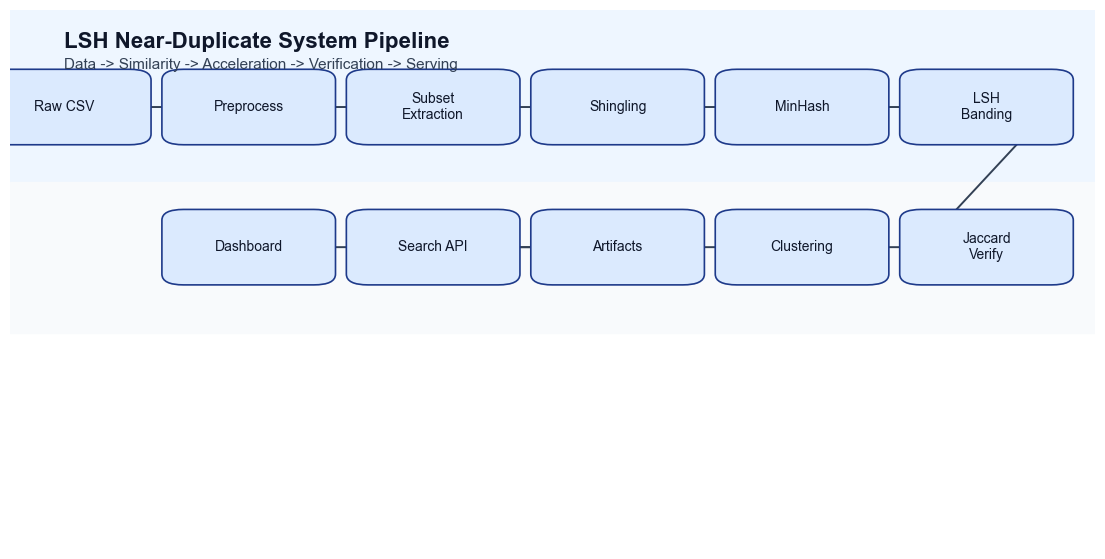

WindowsPath('F:/UK-Russia/jupyter/output/lsh/figures/system_pipeline_diagram.png')

In [10]:
# 9. Vẽ ảnh sơ đồ hệ thống (PNG)
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

nodes = {
    "Raw CSV": (0.05, 0.82),
    "Preprocess": (0.22, 0.82),
    "Subset\nExtraction": (0.39, 0.82),
    "Shingling": (0.56, 0.82),
    "MinHash": (0.73, 0.82),
    "LSH\nBanding": (0.90, 0.82),
    "Jaccard\nVerify": (0.90, 0.56),
    "Clustering": (0.73, 0.56),
    "Artifacts": (0.56, 0.56),
    "Search API": (0.39, 0.56),
    "Dashboard": (0.22, 0.56),
}

edges = [
    ("Raw CSV", "Preprocess"),
    ("Preprocess", "Subset\nExtraction"),
    ("Subset\nExtraction", "Shingling"),
    ("Shingling", "MinHash"),
    ("MinHash", "LSH\nBanding"),
    ("LSH\nBanding", "Jaccard\nVerify"),
    ("Jaccard\nVerify", "Clustering"),
    ("Clustering", "Artifacts"),
    ("Artifacts", "Search API"),
    ("Artifacts", "Dashboard"),
]

fig, ax = plt.subplots(figsize=(14, 7))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")

# Background gradient-like bands
ax.axhspan(0.68, 1.00, color="#eef6ff", zorder=0)
ax.axhspan(0.40, 0.68, color="#f8fafc", zorder=0)

box_w, box_h = 0.12, 0.10
for label, (x, y) in nodes.items():
    rect = FancyBboxPatch(
        (x - box_w / 2, y - box_h / 2),
        box_w,
        box_h,
        boxstyle="round,pad=0.02,rounding_size=0.02",
        linewidth=1.2,
        edgecolor="#1e3a8a",
        facecolor="#dbeafe",
        zorder=2,
    )
    ax.add_patch(rect)
    ax.text(x, y, label, ha="center", va="center", fontsize=10, color="#0f172a", zorder=3)

for src, dst in edges:
    x1, y1 = nodes[src]
    x2, y2 = nodes[dst]
    arrow = FancyArrowPatch(
        (x1 + (box_w / 2 if x2 >= x1 else -box_w / 2), y1),
        (x2 - (box_w / 2 if x2 >= x1 else -box_w / 2), y2),
        arrowstyle="->",
        mutation_scale=12,
        linewidth=1.4,
        color="#334155",
        zorder=1,
        connectionstyle="arc3,rad=0.0",
    )
    ax.add_patch(arrow)

ax.text(0.05, 0.93, "LSH Near-Duplicate System Pipeline", fontsize=16, weight="bold", color="#0f172a")
ax.text(0.05, 0.89, "Data -> Similarity -> Acceleration -> Verification -> Serving", fontsize=11, color="#334155")

output_path = FIGURE_DIR / "system_pipeline_diagram.png"
fig.savefig(output_path, dpi=180, bbox_inches="tight")
plt.show()

output_path

## 9. Tóm tắt báo cáo: mục đích, khó khăn dữ liệu lớn, kết quả 8 tuần

Phần này sinh tự động đoạn văn bản ngắn để chèn vào báo cáo đồ án.

In [11]:
from IPython.display import Markdown, display

baseline_rows = METRICS['extract_subsets']['baseline_rows']
scale_rows = METRICS['extract_subsets']['scale_rows']
kept_rows = METRICS['build_shingles']['scale_shingles']['kept_rows']
positive_pairs = METRICS['baseline']['positive_pairs']
candidate_pairs = METRICS['run_lsh']['scale_run']['candidate_pairs']
verified_pairs = METRICS['verify_and_cluster']['verified_pairs']
clusters_count = METRICS['verify_and_cluster']['clusters']
largest_cluster = METRICS['verify_and_cluster']['largest_cluster_size']

report_text = f"""
### 9.1 Mục đích bài toán
Đề tài tập trung phát hiện và gom cụm nội dung trùng hoặc gần trùng trên dữ liệu thảo luận về xung đột Nga-Ukraine, nhằm hỗ trợ phân tích mức độ lan truyền thông điệp và theo dõi xu hướng dư luận theo thời gian.

### 9.2 Khó khăn khi xử lý dữ liệu lớn
1. Khối lượng dữ liệu lớn, không thể so sánh mọi cặp văn bản theo brute-force ở toàn bộ tập dữ liệu.
2. Dữ liệu nhiễu và không đồng nhất (lỗi dòng, khác định dạng, trùng lặp xuyên ngày), cần bước chuẩn hóa và lọc kỹ.
3. Bài toán có độ phức tạp cao, phải cân bằng giữa tốc độ xử lý và chất lượng phát hiện near-duplicate.

### 9.3 Kết quả đạt được sau 8 tuần
1. Hoàn thiện pipeline end-to-end: tiền xử lý, shingling, baseline, MinHash, LSH, verify, clustering và demo.
2. Trên tập baseline {baseline_rows:,} tweet, brute-force xác định {positive_pairs:,} cặp near-duplicate làm ground truth để tune cấu hình.
3. Trên tập scale {scale_rows:,} tweet, hệ thống giữ lại {kept_rows:,} tweet đủ điều kiện shingling.
4. MinHash + LSH rút không gian so sánh về {candidate_pairs:,} candidate pairs, sau verify giữ lại {verified_pairs:,} cặp near-duplicate thực sự.
5. Kết quả clustering tạo ra {clusters_count:,} cụm, cụm lớn nhất có {largest_cluster:,} tweet, cho thấy hiện tượng lặp nội dung rõ rệt.

### 9.4 Kết luận ngắn
Giải pháp Jaccard + MinHash + LSH phù hợp cho bài toán phát hiện nội dung lặp ở quy mô lớn vì vừa đảm bảo chất lượng phát hiện, vừa giảm mạnh chi phí tính toán so với so sánh toàn cặp.
"""

display(Markdown(report_text))


### 9.1 Mục đích bài toán
Đề tài tập trung phát hiện và gom cụm nội dung trùng hoặc gần trùng trên dữ liệu thảo luận về xung đột Nga-Ukraine, nhằm hỗ trợ phân tích mức độ lan truyền thông điệp và theo dõi xu hướng dư luận theo thời gian.

### 9.2 Khó khăn khi xử lý dữ liệu lớn
1. Khối lượng dữ liệu lớn, không thể so sánh mọi cặp văn bản theo brute-force ở toàn bộ tập dữ liệu.
2. Dữ liệu nhiễu và không đồng nhất (lỗi dòng, khác định dạng, trùng lặp xuyên ngày), cần bước chuẩn hóa và lọc kỹ.
3. Bài toán có độ phức tạp cao, phải cân bằng giữa tốc độ xử lý và chất lượng phát hiện near-duplicate.

### 9.3 Kết quả đạt được sau 8 tuần
1. Hoàn thiện pipeline end-to-end: tiền xử lý, shingling, baseline, MinHash, LSH, verify, clustering và demo.
2. Trên tập baseline 3,000 tweet, brute-force xác định 111 cặp near-duplicate làm ground truth để tune cấu hình.
3. Trên tập scale 50,000 tweet, hệ thống giữ lại 49,852 tweet đủ điều kiện shingling.
4. MinHash + LSH rút không gian so sánh về 36,487 candidate pairs, sau verify giữ lại 31,875 cặp near-duplicate thực sự.
5. Kết quả clustering tạo ra 42,519 cụm, cụm lớn nhất có 60 tweet, cho thấy hiện tượng lặp nội dung rõ rệt.

### 9.4 Kết luận ngắn
Giải pháp Jaccard + MinHash + LSH phù hợp cho bài toán phát hiện nội dung lặp ở quy mô lớn vì vừa đảm bảo chất lượng phát hiện, vừa giảm mạnh chi phí tính toán so với so sánh toàn cặp.
